# Multi-Touch Attribution — Exploratory Data Analysis

This notebook explores the simulated DTC dataset before any modelling.
We examine journey patterns, channel distributions, and conversion rates
by experiment arm to build intuition for the attribution analysis ahead.

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import os

# Plot styling
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✓ Libraries loaded")

✓ Libraries loaded


In [3]:
# ── Connect to DuckDB and load CSVs ───────────────────────────────────────────
BASE_DIR = os.path.expanduser(
    "/Users/annecarroll/Dropbox/github/02_mta/mta-ab-project"
)

RAW_DIR = os.path.join(BASE_DIR, "data", "raw")

con = duckdb.connect()

con.execute(f"""
    CREATE TABLE user_touchpoints AS
    SELECT * FROM read_csv_auto('{RAW_DIR}/user_touchpoints.csv')
""")

con.execute(f"""
    CREATE TABLE conversions AS
    SELECT * FROM read_csv_auto('{RAW_DIR}/conversions.csv')
""")

con.execute(f"""
    CREATE TABLE experiment_assignments AS
    SELECT * FROM read_csv_auto('{RAW_DIR}/experiment_assignments.csv')
""")

print("✓ Tables loaded")
print(f"  Touchpoints:  {con.execute('SELECT COUNT(*) FROM user_touchpoints').fetchone()[0]:,}")
print(f"  Conversions:  {con.execute('SELECT COUNT(*) FROM conversions').fetchone()[0]:,}")
print(f"  Assignments:  {con.execute('SELECT COUNT(*) FROM experiment_assignments').fetchone()[0]:,}")

✓ Tables loaded
  Touchpoints:  199,532
  Conversions:  5,593
  Assignments:  50,000


## 1. Journey Length Distribution

How many ad touchpoints does a typical user have before converting?
Understanding journey length is foundational for attribution —
a user with 1 touchpoint is easy to attribute; a user with 7 is not.

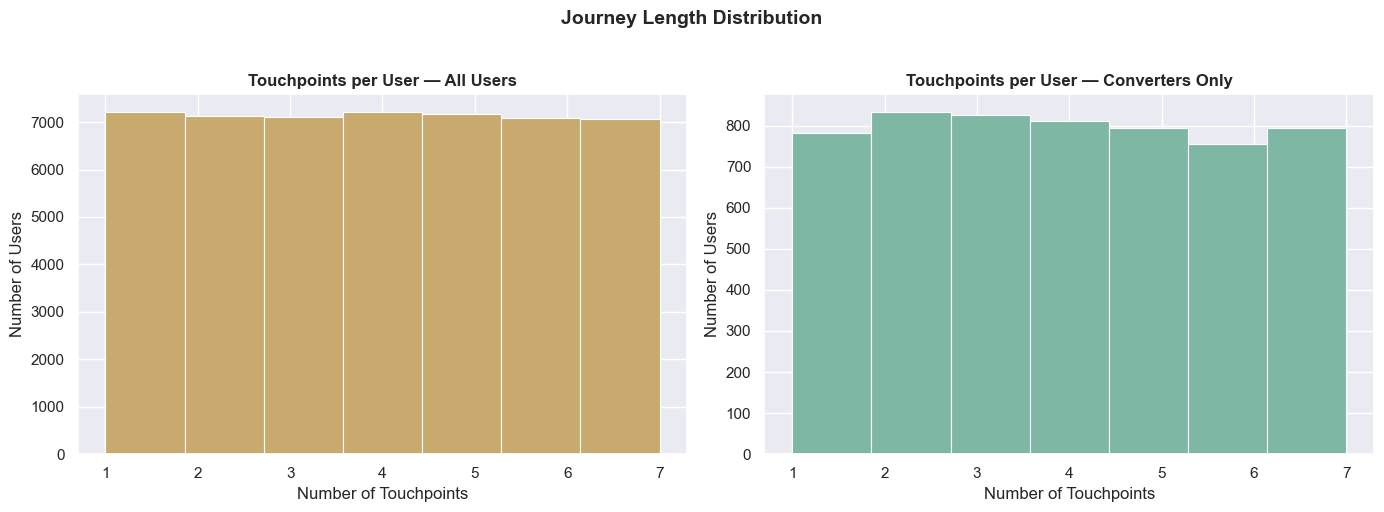

  Avg touchpoints (all users):    4.0
  Avg touchpoints (converters):   4.0


In [4]:
# ── Journey length distribution ───────────────────────────────────────────────
journey_lengths = con.execute("""
    SELECT
        user_id,
        COUNT(*) AS n_touchpoints
    FROM user_touchpoints
    GROUP BY user_id
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — all users
axes[0].hist(journey_lengths['n_touchpoints'], bins=7,
             color='#C8A96E', edgecolor='white', linewidth=0.8)
axes[0].set_title('Touchpoints per User — All Users', fontweight='bold')
axes[0].set_xlabel('Number of Touchpoints')
axes[0].set_ylabel('Number of Users')

# Right — converters only
converters = con.execute("""
    SELECT tp.user_id, COUNT(*) AS n_touchpoints
    FROM user_touchpoints tp
    JOIN conversions c ON tp.user_id = c.user_id
    GROUP BY tp.user_id
""").df()

axes[1].hist(converters['n_touchpoints'], bins=7,
             color='#7EB8A4', edgecolor='white', linewidth=0.8)
axes[1].set_title('Touchpoints per User — Converters Only', fontweight='bold')
axes[1].set_xlabel('Number of Touchpoints')
axes[1].set_ylabel('Number of Users')

plt.suptitle('Journey Length Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'assets', 'journey_length.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"  Avg touchpoints (all users):    {journey_lengths['n_touchpoints'].mean():.1f}")
print(f"  Avg touchpoints (converters):   {converters['n_touchpoints'].mean():.1f}")

### Observation
Journey length is uniformly distributed across 1–7 touchpoints with an average
of 4.0 for both all users and converters. In a real DTC dataset we'd expect a
right skew — most users seeing 1–2 ads before converting or dropping off.
The flat distribution here reflects the simulation design and doesn't affect
the validity of the attribution models.